# Q1 — Does predictive model averaging improve generalization?

Hypothesis: BPMA should improve proper predictive scores when plausible families make complementary errors, without a large penalty when one family is clearly best. Compare BPMA with a single selected model and equal-weight averaging using the same fitted draw population.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from EXPERIMENTS.common import classification_data, split_data, fit_classifier

In [2]:
X, y = classification_data(seed=7, kind='nonlinear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=7)
bpma = fit_classifier(X_train, y_train, seed=7)
bpma_proba = bpma.predict_proba(X_test)
equal_proba = np.mean([draw.estimator.predict_proba(X_test) for draw in bpma._models], axis=0)
single = LogisticRegression(max_iter=2000).fit(X_train, y_train)
single_proba = single.predict_proba(X_test)
results = {
    'BPMA': (log_loss(y_test, bpma_proba), brier_score_loss(y_test, bpma_proba[:, 1]), accuracy_score(y_test, np.argmax(bpma_proba, axis=1))),
    'equal weight': (log_loss(y_test, equal_proba), brier_score_loss(y_test, equal_proba[:, 1]), accuracy_score(y_test, np.argmax(equal_proba, axis=1))),
    'single logistic': (log_loss(y_test, single_proba), brier_score_loss(y_test, single_proba[:, 1]), accuracy_score(y_test, np.argmax(single_proba, axis=1))),
}
results

{'BPMA': (0.42457455448218745, 0.12934496459656628, 0.8533333333333334),
 'equal weight': (0.4272134117712695, 0.13025837474122065, 0.8533333333333334),
 'single logistic': (0.5038991720487466,
  0.1633252345530953,
  0.7866666666666666)}

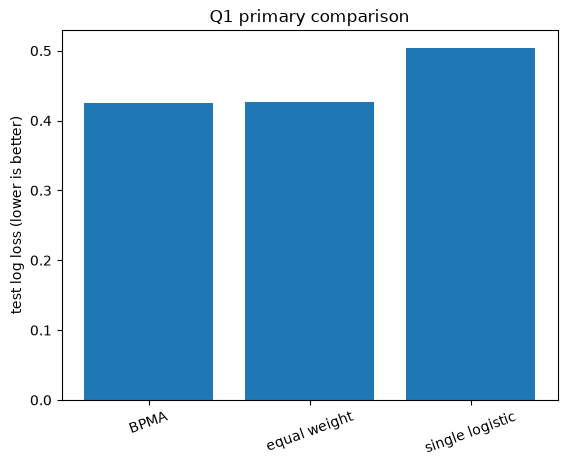

In [3]:
names = list(results)
plt.bar(names, [results[name][0] for name in names])
plt.ylabel('test log loss (lower is better)')
plt.title('Q1 primary comparison')
plt.xticks(rotation=20)
plt.show()

# Extend this cell over outer splits and data seeds before drawing a conclusion.


## Conclusion from the executed starter run

**Status: not falsified; preliminary support.** BPMA achieved test log loss 0.4246 versus 0.4272 for equal-weight averaging and 0.5039 for the single logistic baseline, with identical accuracy for the two averaging methods. This is one nonlinear split and not a nested, repeated benchmark, so it supports the hypothesis only provisionally.